# Credit Risk Prediction System
## End-to-End Machine Learning Pipeline

**Author:** Ayushi Patel  
**Dataset:** Give Me Some Credit - Kaggle  
**Goal:** Predict the probability that a loan applicant will experience financial distress in the next 2 years, enabling data-driven credit decisions.

---

### What am I building here?

I'm building a machine learning model that predicts whether a loan applicant is likely to default within the next 2 years. This is a classic credit risk problem that every bank and fintech company deals with.

The idea is simple: if a bank approves a risky loan, they lose money. If they reject a good customer, they lose business. A well-calibrated ML model helps make that decision smarter.

### What makes this interesting?

- The data has missing values and class imbalance (only ~7% of people actually defaulted)
- I need to think about business cost, not just model accuracy
- I want the model to be explainable, not just accurate (using SHAP)
- Final goal is a live web app where anyone can enter loan details and get a risk prediction

### Notebook Structure
1. **Notebook 1:** Exploratory Data Analysis & Preprocessing
2. **Notebook 2:** Model Training & Experiment Tracking
3. **Notebook 3:** Model Evaluation & Explainability

## Step 1: Importing Libraries

Before anything else, I'm loading all the libraries I'll need for data exploration and visualization. I'll import additional ones in later notebooks as needed.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Make plots look clean
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Libraries loaded successfully!
Pandas version: 2.3.3
Numpy version: 2.2.6


## Step 2: Loading the Data

Loading the dataset and doing a first look. The dataset has 150,000 loan applicants with 11 features and 1 target variable (SeriousDlqin2yrs).

In [2]:
# Load the dataset
df = pd.read_csv('../data/credit_data.csv', index_col=0)

# First look
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 150000
Columns: 11


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Step 3: Understanding the Columns

Before doing anything, I want to know what each column actually means in business terms. This matters because later I'll need to explain my model decisions to non-technical stakeholders.

In [3]:
# Column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [4]:
# What does each column mean?
column_descriptions = {
    'SeriousDlqin2yrs': 'TARGET: 1 = defaulted within 2 years, 0 = did not default',
    'RevolvingUtilizationOfUnsecuredLines': 'How much of credit limit is being used (0 to 1)',
    'age': 'Age of the borrower in years',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Times 30-59 days late on payment',
    'DebtRatio': 'Monthly debt payments divided by monthly income',
    'MonthlyIncome': 'Monthly income in dollars',
    'NumberOfOpenCreditLinesAndLoans': 'Number of open loans and credit lines',
    'NumberOfTimes90DaysLate': 'Times 90+ days late on payment',
    'NumberRealEstateLoansOrLines': 'Number of mortgage and real estate loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Times 60-89 days late on payment',
    'NumberOfDependents': 'Number of dependents in family'
}

print("Column descriptions:\n")
for col, desc in column_descriptions.items():
    print(f"{col}: {desc}")

Column descriptions:

SeriousDlqin2yrs: TARGET: 1 = defaulted within 2 years, 0 = did not default
RevolvingUtilizationOfUnsecuredLines: How much of credit limit is being used (0 to 1)
age: Age of the borrower in years
NumberOfTime30-59DaysPastDueNotWorse: Times 30-59 days late on payment
DebtRatio: Monthly debt payments divided by monthly income
MonthlyIncome: Monthly income in dollars
NumberOfOpenCreditLinesAndLoans: Number of open loans and credit lines
NumberOfTimes90DaysLate: Times 90+ days late on payment
NumberRealEstateLoansOrLines: Number of mortgage and real estate loans
NumberOfTime60-89DaysPastDueNotWorse: Times 60-89 days late on payment
NumberOfDependents: Number of dependents in family


## Step 4: Basic Statistics

Looking at summary statistics to understand the range, mean and spread of each feature. This helps spot obvious data quality issues right away.

In [5]:
# Statistical summary
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.000000,0.066840,0.249746,0.000000,0.000000,0.000000,0.000000,1.000000
RevolvingUtilizationOfUnsecuredLines,150000.000000,6.048438,249.755371,0.000000,0.029867,0.154181,0.559046,50708.000000
age,150000.000000,52.295207,14.771866,0.000000,41.000000,52.000000,63.000000,109.000000
NumberOfTime30-59DaysPastDueNotWorse,150000.000000,0.421033,4.192781,0.000000,0.000000,0.000000,0.000000,98.000000
DebtRatio,150000.000000,353.005076,2037.818523,0.000000,0.175074,0.366508,0.868254,329664.000000
MonthlyIncome,120269.000000,6670.221237,14384.674215,0.000000,3400.000000,5400.000000,8249.000000,3008750.000000
NumberOfOpenCreditLinesAndLoans,150000.000000,8.452760,5.145951,0.000000,5.000000,8.000000,11.000000,58.000000
NumberOfTimes90DaysLate,150000.000000,0.265973,4.169304,0.000000,0.000000,0.000000,0.000000,98.000000
NumberRealEstateLoansOrLines,150000.000000,1.018240,1.129771,0.000000,0.000000,1.000000,2.000000,54.000000
NumberOfTime60-89DaysPastDueNotWorse,150000.000000,0.240387,4.155179,0.000000,0.000000,0.000000,0.000000,98.000000


## Step 5: Checking the Target Variable

The target variable is SeriousDlqin2yrs. We need to examine how balanced it is.

In real-world credit data, defaults are usually rare. This situation is known as class imbalance, and it is one of the most important challenges in credit risk modeling.

Non-default (0): 139,974
Default (1):     10,026
Default rate:    6.68%


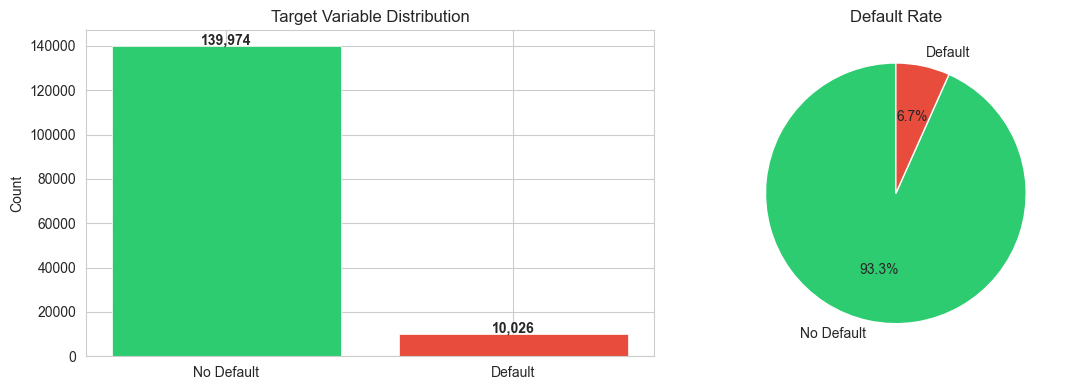


Observation: Only ~6.7% of applicants defaulted.
This is class imbalance, I will handle this in Notebook 2 using SMOTE.


In [6]:
# Target distribution
target_counts = df['SeriousDlqin2yrs'].value_counts()
default_rate = df['SeriousDlqin2yrs'].mean() * 100

print(f"Non-default (0): {target_counts[0]:,}")
print(f"Default (1):     {target_counts[1]:,}")
print(f"Default rate:    {default_rate:.2f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['No Default', 'Default'], target_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Default', 'Default'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Default Rate')

plt.tight_layout()
plt.savefig('../data/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservation: Only ~6.7% of applicants defaulted.")
print("This is class imbalance, I will handle this in Notebook 2 using SMOTE.")

## Step 6: Missing Values Analysis

Real datasets always have missing data. I need to find where they are, how many, and decide how to handle them. Dropping rows with missing data is almost never the right answer in production.

                    Missing Count  Missing Percentage
MonthlyIncome               29731               19.82
NumberOfDependents           3924                2.62


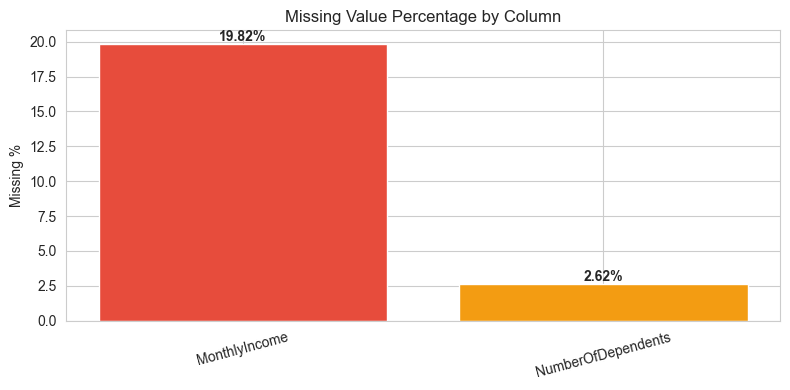


Observation: MonthlyIncome has ~19.8% missing and NumberOfDependents has ~2.6% missing.
I will impute these rather than drop rows.


In [7]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
}).sort_values('Missing Percentage', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

# Plot
missing_cols = missing_df[missing_df['Missing Count'] > 0]
plt.figure(figsize=(8, 4))
plt.bar(missing_cols.index, missing_cols['Missing Percentage'], 
        color=['#e74c3c', '#f39c12'])
plt.title('Missing Value Percentage by Column')
plt.ylabel('Missing %')
plt.xticks(rotation=15)
for i, v in enumerate(missing_cols['Missing Percentage']):
    plt.text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservation: MonthlyIncome has ~19.8% missing and NumberOfDependents has ~2.6% missing.")
print("I will impute these rather than drop rows.")

## Step 7: Distribution of Features

Plotting distributions for all numerical features to understand their shape, skewness and outliers. This directly informs which features need transformation.

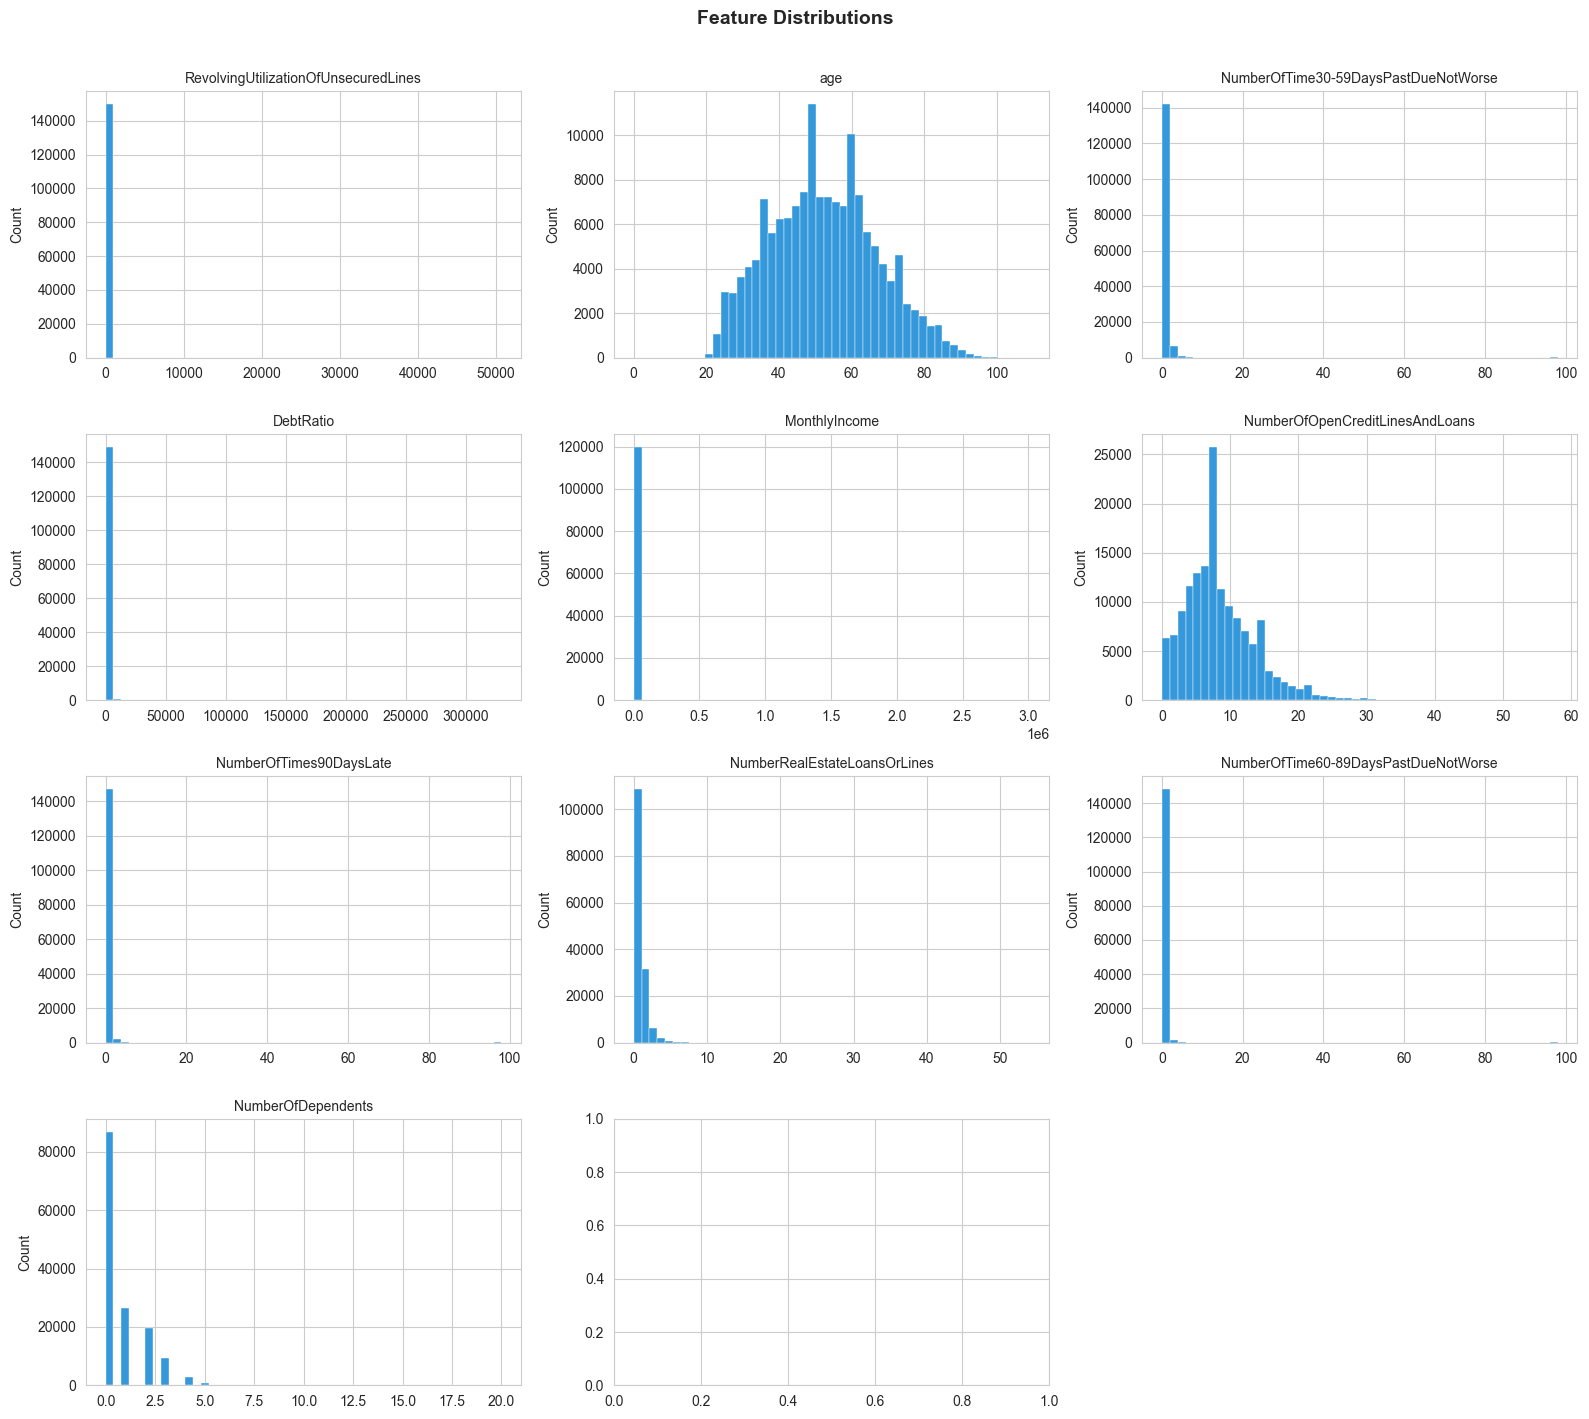

Observation: Most features are heavily right-skewed with extreme outliers.
RevolvingUtilization and DebtRatio have values way above 1 which are likely data errors.


In [8]:
# Distribution plots for all features
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=50, color='#3498db', edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: Most features are heavily right-skewed with extreme outliers.")
print("RevolvingUtilization and DebtRatio have values way above 1 which are likely data errors.")

## Step 8: Outlier Detection

Some columns have extreme values that don't make business sense. For example, a debt ratio of 300,000 is not realistic. I need to identify and cap these outliers.

In [9]:
# Check extreme values in key columns
outlier_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
    'age'
]

for col in outlier_cols:
    print(f"{col}:")
    print(f"  Min: {df[col].min():.2f}  |  Max: {df[col].max():.2f}  |  Mean: {df[col].mean():.2f}  |  Median: {df[col].median():.2f}")
    print()

RevolvingUtilizationOfUnsecuredLines:
  Min: 0.00  |  Max: 50708.00  |  Mean: 6.05  |  Median: 0.15

DebtRatio:
  Min: 0.00  |  Max: 329664.00  |  Mean: 353.01  |  Median: 0.37

MonthlyIncome:
  Min: 0.00  |  Max: 3008750.00  |  Mean: 6670.22  |  Median: 5400.00

age:
  Min: 0.00  |  Max: 109.00  |  Mean: 52.30  |  Median: 52.00



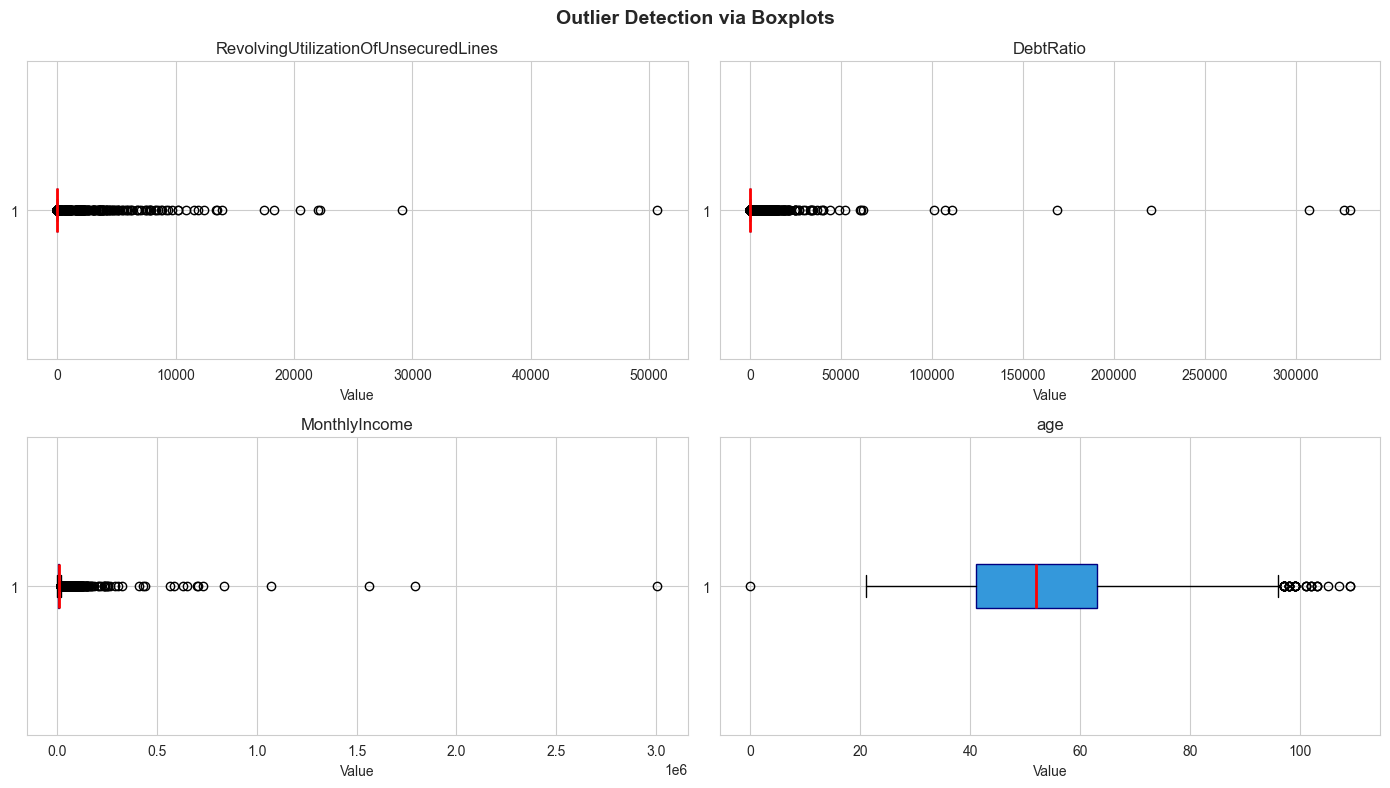

In [10]:
# Boxplots to visualize outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')

plt.suptitle('Outlier Detection via Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/outliers.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Feature vs Target Analysis

Now I want to see how each feature relates to the target variable. This is key for feature selection and understanding what actually drives defaults.

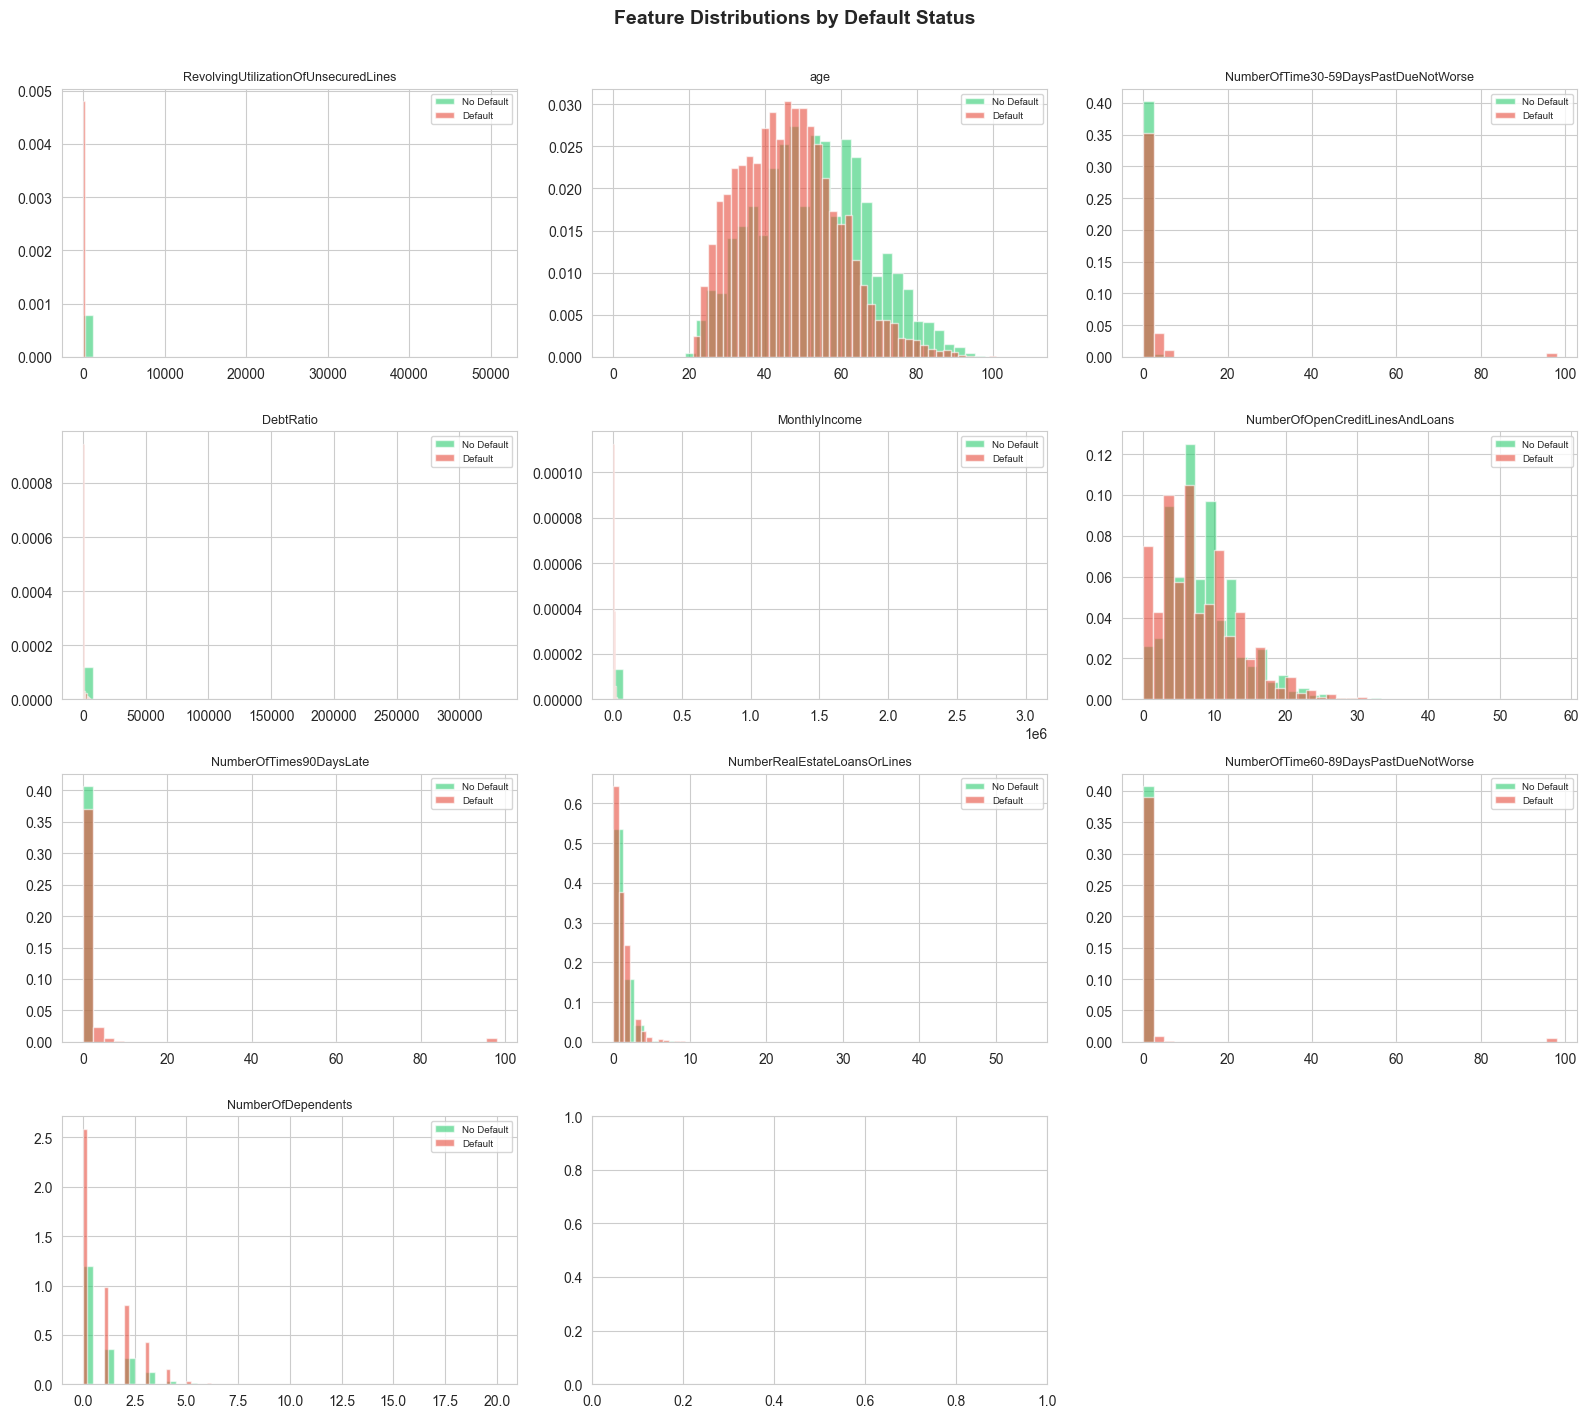

In [11]:
# Compare feature distributions for defaulters vs non-defaulters
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    default = df[df['SeriousDlqin2yrs'] == 1][col].dropna()
    no_default = df[df['SeriousDlqin2yrs'] == 0][col].dropna()
    
    axes[i].hist(no_default, bins=40, alpha=0.6, color='#2ecc71', label='No Default', density=True)
    axes[i].hist(default, bins=40, alpha=0.6, color='#e74c3c', label='Default', density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Default Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/features_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

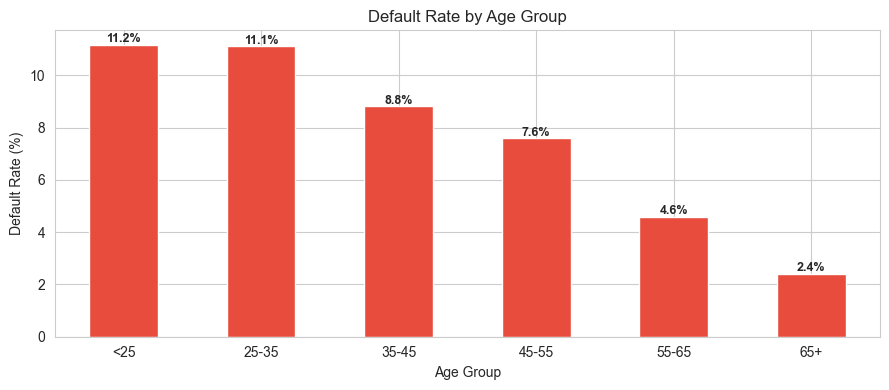

In [12]:
# Default rate by age group
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100],
                          labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])

age_default = df.groupby('age_group', observed=True)['SeriousDlqin2yrs'].mean() * 100

plt.figure(figsize=(9, 4))
age_default.plot(kind='bar', color='#e74c3c', edgecolor='white')
plt.title('Default Rate by Age Group')
plt.ylabel('Default Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
for i, v in enumerate(age_default):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/default_rate_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Correlation Analysis

Checking correlations between all features and the target. High correlation with the target = useful feature. High correlation between two features = multicollinearity problem.

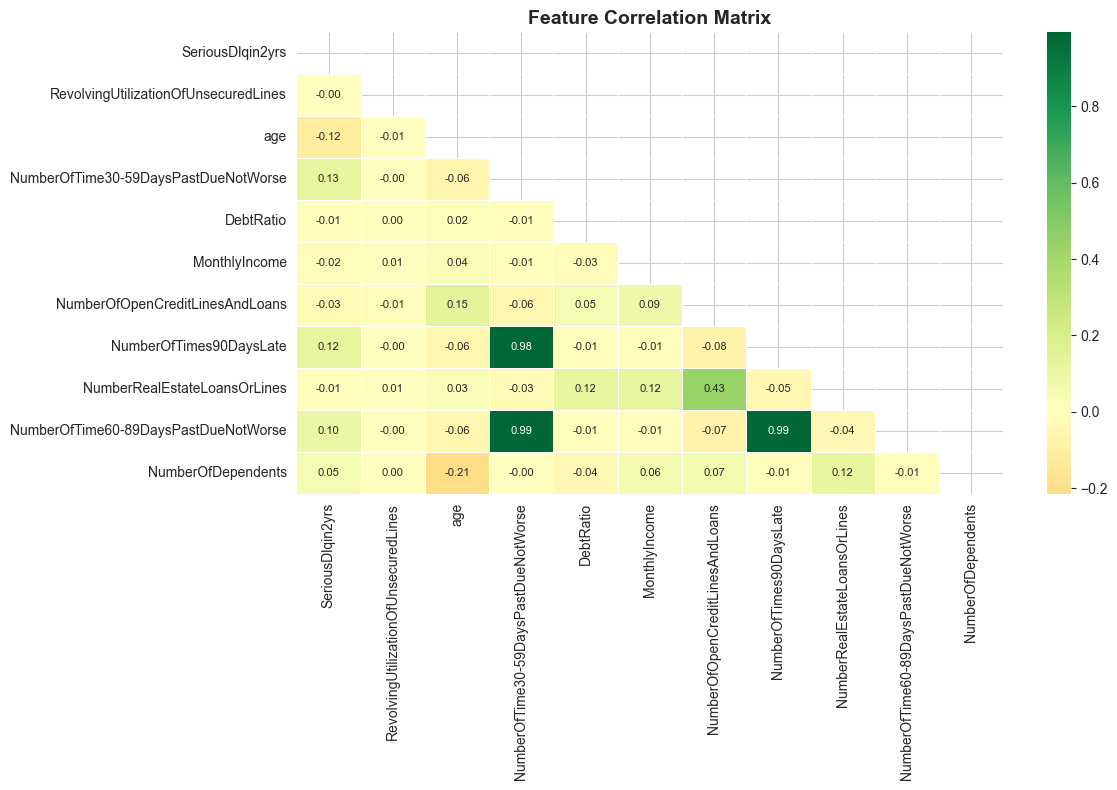

Correlation with target (SeriousDlqin2yrs):

NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64


In [13]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.drop(columns=['age_group']).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation with target specifically
print("Correlation with target (SeriousDlqin2yrs):\n")
target_corr = corr_matrix['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values(ascending=False)
print(target_corr)

## Step 11: Data Preprocessing

Now I clean and prepare the data for modeling. This includes:
- Handling missing values with median imputation
- Capping outliers at realistic business thresholds
- Dropping the helper column I created for EDA
- Splitting into train and test sets

In [14]:
# Work on a clean copy
df_clean = df.drop(columns=['age_group']).copy()

# 1. Impute missing values with median (robust to outliers)
df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median(), inplace=True)
df_clean['NumberOfDependents'].fillna(df_clean['NumberOfDependents'].median(), inplace=True)

# Verify no missing values remain
print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


C:\Users\ayush\AppData\Local\Temp\ipykernel_32316\532150328.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median(), inplace=True)
C:\Users\ayush\AppData\Local\Temp\ipykernel_32316\532150328.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [15]:
# 2. Cap outliers at realistic thresholds
# RevolvingUtilization should be between 0 and 1
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

# DebtRatio above 10 is not realistic
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(0, 10)

# Age should be between 18 and 100
df_clean['age'] = df_clean['age'].clip(18, 100)

# Monthly income cap at 99th percentile
income_cap = df_clean['MonthlyIncome'].quantile(0.99)
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].clip(0, income_cap)

print("Outlier capping done.")
print(f"RevolvingUtilization max: {df_clean['RevolvingUtilizationOfUnsecuredLines'].max()}")
print(f"DebtRatio max: {df_clean['DebtRatio'].max()}")
print(f"Age range: {df_clean['age'].min()} to {df_clean['age'].max()}")
print(f"MonthlyIncome cap: {income_cap:.2f}")

Outlier capping done.
RevolvingUtilization max: 1.0
DebtRatio max: 10.0
Age range: 18 to 100
MonthlyIncome cap: 23000.00


In [16]:
# 3. Split into features and target
X = df_clean.drop(columns=['SeriousDlqin2yrs'])
y = df_clean['SeriousDlqin2yrs']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {list(X.columns)}")

Features shape: (150000, 10)
Target shape: (150000,)
Feature columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [17]:
from sklearn.model_selection import train_test_split

# 4. Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")
print(f"Default rate in train: {y_train.mean()*100:.2f}%")
print(f"Default rate in test:  {y_test.mean()*100:.2f}%")

Training set:   (120000, 10)
Test set:       (30000, 10)
Default rate in train: 6.68%
Default rate in test:  6.68%


In [18]:
import joblib
import os

# 5. Save the processed data for Notebook 2
os.makedirs('../data/processed', exist_ok=True)

joblib.dump((X_train, X_test, y_train, y_test), '../data/processed/train_test_split.pkl')

print("Processed data saved to ../data/processed/train_test_split.pkl")

Processed data saved to ../data/processed/train_test_split.pkl


## Summary

Here is what I found and did in this notebook:

- Dataset has 150,000 rows and 11 features with 1 binary target
- Only 6.7% of applicants defaulted, indicating significant class imbalance that will be handled in the next stage
- Two columns had missing values: MonthlyIncome (about 19.8%) and NumberOfDependents (about 2.6%), imputed with median
- Several columns had unrealistic outliers (DebtRatio, RevolvingUtilization), capped at business-logical thresholds
- Younger borrowers (25-35) show higher default rates
- Late payment history features have the highest correlation with default
- Data split into 80% train and 20% test with stratification to preserve default rate

Next, the focus will shift to building and evaluating machine learning models using this prepared dataset(Notebook 2).